In [1]:
import pyarrow.parquet as pq
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import IterableDataset, DataLoader
from tqdm import tqdm

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import  accuracy_score, classification_report
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
import torch.nn.functional as F

## Config

In [2]:
# ---------------------------------------
# Configuration
# ---------------------------------------
parquet_path = 'MasterDS/Master_cleaned.parquet'
return_col   = 'ret_5d_future' # Column to predict
batch_size   = 4096
n_epochs     = 15  # number of training epochs
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ---------------------------------------
# Prepare ParquetFile and feature columns
# ---------------------------------------
pf = pq.ParquetFile(parquet_path)
all_cols = pf.schema_arrow.names
exclude  = {return_col, 'date', 'ticker'}
feature_cols = [c for c in all_cols if c not in exclude]

# ---------------------------------------
# Precompute date-wise cutoff map
# ---------------------------------------
cutoff_lists, all_dates = {}, set()
for batch in pf.iter_batches(batch_size=1_500_000):
    dfb = batch.to_pandas()[['date', return_col]]
    for date, grp in dfb.groupby('date'):
        all_dates.add(date)
        cutoff_lists.setdefault(date, []).extend(grp[return_col].values)
cutoff_map = {date: np.quantile(vals, 0.95) for date, vals in cutoff_lists.items()}
all_dates = sorted(all_dates)
n_total = len(all_dates)
train_idx = int(n_total * 0.8) # 80% for training, 20% for testing

train_dates = set(all_dates[:train_idx])
test_dates  = set(all_dates[train_idx:])


# ---------------------------------------
# Fit scaler on a sample group of rows
# ---------------------------------------

calib_frames = []
n_groups = min(20, pf.num_row_groups)
for i in range(n_groups):
    # grab a small random sample from each row-group
    df_rg = pf.read_row_group(i).to_pandas()[feature_cols]
    calib_frames.append(df_rg.sample(n=5000, random_state=42))

calib = pd.concat(calib_frames, axis=0)
feature_scaler = StandardScaler().fit(calib.values)

# ---------------------------------------
# Define IterableDataset for streaming
# ---------------------------------------
class ParquetDataset(IterableDataset):
    """
    Streams batches from the Parquet file without any class-balancing.
    Each yielded tuple is (xb, yb, meta) where:
        xb   : torch.FloatTensor  [batch_size, n_features]
        yb   : torch.FloatTensor  [batch_size]   (0/1 labels)
        meta : np.ndarray         [batch_size, 2]  (date, ticker)
    """
    def __init__(self, dates_subset, pos_ratio=None, batch_size=4096):
        self.dates_subset = dates_subset
        self.pos_ratio = pos_ratio
        self.batch_size = batch_size

    def __iter__(self):
        local_pf = pq.ParquetFile(parquet_path)

        for batch in local_pf.iter_batches(batch_size=self.batch_size * 4):
            df = batch.to_pandas()
            df = df[df["date"].isin(self.dates_subset)]
            if df.empty:
                continue

            # create label
            df["label"] = (df[return_col] >= df["date"].map(cutoff_map)).astype(np.int8)

            # filter finite rows
            X_raw = df[feature_cols].values.astype(np.float32)
            y_raw = df["label"].values.astype(np.int8)
            mask  = np.isfinite(X_raw).all(axis=1)
            if not mask.any():
                continue

            X     = feature_scaler.transform(X_raw[mask])
            X = np.clip(X, -5.0, +5.0)
            y     = y_raw[mask]
            meta  = df.loc[mask, ["date", "ticker"]].values

            if self.pos_ratio is not None:
                idx_pos = np.where(y == 1)[0]
                idx_neg = np.where(y == 0)[0]

                if len(idx_pos) == 0 or len(idx_neg) == 0:
                    continue  # skip batch if only one class

                n_pos = int(self.batch_size * self.pos_ratio)
                n_neg = self.batch_size - n_pos

                choose_pos = np.random.choice(idx_pos, n_pos, replace=len(idx_pos) < n_pos)
                choose_neg = np.random.choice(idx_neg, n_neg, replace=len(idx_neg) < n_neg)

                sel = np.concatenate([choose_pos, choose_neg])
                np.random.shuffle(sel)

                X, y, meta = X[sel], y[sel], meta[sel]
            else:
                if len(y) > self.batch_size:
                    sel = np.random.choice(len(y), self.batch_size, replace=False)
                    X, y, meta = X[sel], y[sel], meta[sel]

            # convert to tensors
            xb = torch.from_numpy(X).to(device)
            yb = torch.from_numpy(y.astype(np.float32)).to(device)

            yield xb, yb, meta


Using device: cuda


## Train

In [3]:
class FocalLoss(nn.Module):
    """
    Focal Loss for binary classification
      L = - alpha * (1 - p_t)^gamma * log(p_t)
    where p_t = sigmoid(logits) if y=1, or 1 - sigmoid(logits) if y=0.
    """

    def __init__(self, alpha: float = 0.25, gamma: float = 2.0, reduction: str = "mean"):
        """
        Args:
            alpha: weight for the positive class (in [0,1])
            gamma: focusing parameter (>=0)
            reduction: 'none' | 'mean' | 'sum'
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits: raw network output of shape [B]
            targets: binary labels (0 or 1) of shape [B]
        Returns:
            loss: scalar (if reduction!='none') or per-sample loss [B]
        """
        # compute binary cross entropy per sample
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")  # [B]

        # p_t = sigmoid(logits) when y=1, else 1 - sigmoid(logits)
        prob = torch.sigmoid(logits)
        p_t = targets * prob + (1 - targets) * (1 - prob)

        # focal weight factor
        weight = self.alpha * (1 - p_t).pow(self.gamma)

        loss = weight * bce

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:  # 'none'
            return loss

# ---------------------------------------
# Create DataLoaders without multiprocessing
# ---------------------------------------
train_ds = ParquetDataset(train_dates, pos_ratio=0.5, batch_size=batch_size) #

scan_loader = DataLoader(train_ds, batch_size=None, num_workers=0)
pos, neg = 0, 0
for _, y, _ in scan_loader:        # quick pass for counts
    pos += (y == 1).sum().item()
    neg += (y == 0).sum().item()
pos_weight = torch.tensor([neg / max(pos, 1)], device=device) # Penalizies wrong positive answers more

print("pos_weight =", pos_weight.item())

train_loader = DataLoader(train_ds, batch_size=None, num_workers=0)


# costFN = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
alpha = neg/(pos+neg)
# alpha  = 0.6

gamma = 0.5
costFN = FocalLoss(alpha=alpha, gamma=gamma, reduction="mean")
# costFN = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg/pos], device=device))
class TabMLP(nn.Module):
    def __init__(self,
                 input_dim: int,
                 hidden_layers: list[int] = [512, 256, 128],
                 p_drop: float = 0.3):
        super().__init__()

        layers = []
        dim = input_dim
        for h in hidden_layers:
            layers += [
                nn.Linear(dim, h),
                nn.LayerNorm(h),
                nn.ReLU(inplace=True),
                nn.Dropout(p_drop)
            ]
            dim = h
        layers.append(nn.Linear(dim, 1))        # final logit
        self.net = nn.Sequential(*layers)

    def forward(self, x):                       # x : [B, F]
        return self.net(x).squeeze(1)           # [B]
    

model = TabMLP(input_dim=len(feature_cols)).to(device)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

# Estimate steps per epoch
total_rows   = sum(pf.metadata.row_group(i).num_rows for i in range(pf.num_row_groups))
train_steps = int((total_rows * 0.8) // batch_size)


# ---------------------------------------
# Training loop with tqdm progress bars
# ---------------------------------------

grad_scaler = GradScaler()
for epoch in range(n_epochs):
    # Training
    model.train()
    running = 0
    batch_cnt = 0
    pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")
    for xb, yb, _ in pbar_train:
        # are feature values crazy?
        assert torch.isfinite(xb).all(),  "❌ NaN or Inf in your features!"
        # are labels valid 0/1 floats?
        assert (yb >= 0).all() and (yb <= 1).all(), "❌ Bad labels!"
        optimizer.zero_grad()
        with autocast(device_type="cuda"):
            ypreds = model(xb)
            with torch.no_grad():
                # 1) check feature magnitudes
                max_feat = xb.abs().max().item()
                # 2) check raw logits magnitudes
                max_logit = ypreds.abs().max().item()
            ypreds = ypreds.clamp(-10, +10)
            loss   = costFN(ypreds, yb)
            # print(f"  ▶ max|x|={max_feat:.2e}, max|logit|={max_logit:.2e}, loss={loss.item():.4f}")
            
        grad_scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        grad_scaler.step(optimizer)
        grad_scaler.update()

        running += loss.item()
        batch_cnt += 1
        pbar_train.set_postfix(loss=loss.item())
    
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    

    

    print(f"Epoch {epoch+1}: loss {running/batch_cnt:.4f}, learning rate: {current_lr:.6f}")


# Save trained model
torch.save(model.state_dict(), "models/TopSelector_state_dict.pt")
torch.jit.script(model).save("models/TopSelector.pt")

print("Training complete. Saved:")

pos_weight = 1.0


Epoch 1/15: 422it [01:36,  4.35it/s, loss=0.186]


Epoch 1: loss 0.2111, learning rate: 0.000198


Epoch 2/15: 422it [01:38,  4.30it/s, loss=0.184]


Epoch 2: loss 0.2090, learning rate: 0.000191


...

Epoch 13: loss 0.2069, learning rate: 0.000009


Epoch 14/15: 422it [01:39,  4.25it/s, loss=0.192]


Epoch 14: loss 0.2070, learning rate: 0.000002


Epoch 15/15: 422it [01:33,  4.52it/s, loss=0.187]


Epoch 15: loss 0.2068, learning rate: 0.000000
Training complete. Saved:


## Test

In [6]:
# load model
scripted_model = torch.jit.load("models/TopSelector.pt", map_location=device)
scripted_model.to(device)
scripted_model.eval()

test_ds = ParquetDataset(test_dates)
test_loader = DataLoader(test_ds, batch_size=None, num_workers=0)

best_thresh = 0.6779

results = []
with torch.no_grad():
    for XTest, yTest, meta in test_loader:
        yTestpreds = scripted_model(XTest)
        probs = torch.sigmoid(yTestpreds).cpu().numpy()
        preds = (probs >= best_thresh).astype(np.int8) # Certainty Rating
        labels = yTest.cpu().numpy()

        for i in range(len(probs)):
            date, ticker = meta[i]
            results.append((date, ticker, float(probs[i].item()), int(preds[i].item()), int(labels[i].item())))

# Build DataFrame
test_df = pd.DataFrame(results, columns=["date", "ticker", "prob", "pred", "label"])
test_df["rank_prob"] = test_df.groupby("date")["prob"].rank(method="first", ascending=False)

#Evaluation
accuracy = accuracy_score(test_df["label"], test_df["pred"])
print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(test_df["label"], test_df["pred"], digits=4))

# # Export
# top_150_df = test_df[test_df["rank_prob"] <= 150].copy()
# top_150_df = top_150_df.sort_values(["date", "rank_prob"])
# top_150_df.to_csv("top_150_predictions.csv", index=False)
# print("Exported top 150 predictions per date to top_150_predictions.csv")
# After running inference loop, build DataFrame:
full_df = pd.DataFrame(results, columns=["date","ticker","prob","pred","label"])
# Save everything:
full_df.to_csv("full_test_predictions.csv", index=False)

Test Accuracy: 0.8515

Classification Report:
               precision    recall  f1-score   support

           0     0.9671    0.8729    0.9176   4678609
           1     0.1693    0.4660    0.2483    259964

    accuracy                         0.8515   4938573
   macro avg     0.5682    0.6695    0.5830   4938573
weighted avg     0.9251    0.8515    0.8824   4938573



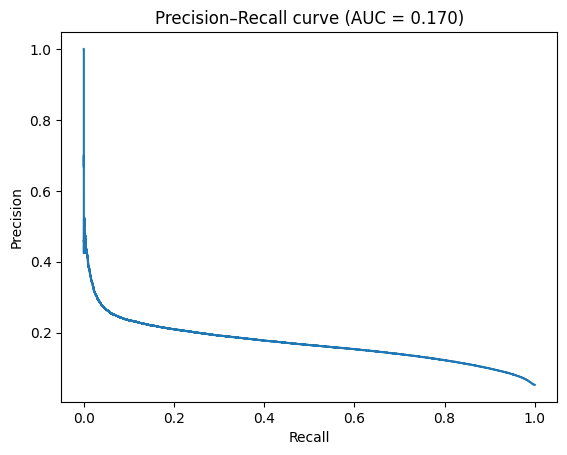

Best F1 = 0.249 at threshold ≥ 0.6690  →  P=0.166, R=0.494
count    3196.000000
mean      241.826033
std       157.914213
min        49.000000
25%       111.000000
50%       173.500000
75%       382.000000
max       842.000000
Name: pred_f1, dtype: float64
Confusion matrix (rows = true class, cols = predicted) [raw counts]
         Pred 0  Pred 1
True 0  4084143  594466
True 1   138829  121135

Confusion matrix (row-normalized, %)
        Pred 0 (%)  Pred 1 (%)
True 0       87.29       12.71
True 1       53.40       46.60

Accuracy            : 0.8515
Balanced accuracy   : 0.6695
AUC (probabilities) : 0.8047
Positives in test   : 5.26%
Predicted positives : 14.49%


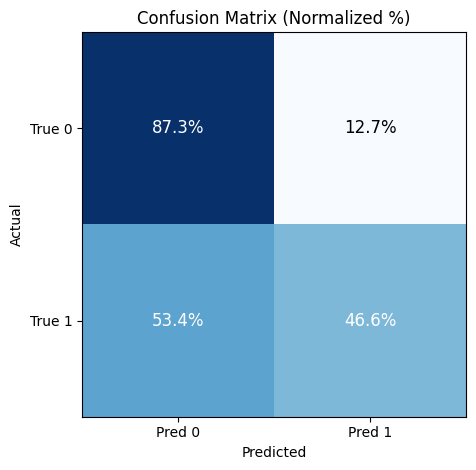

In [7]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

df = pd.read_csv("full_test_predictions.csv")
y_true = df["label"]
y_scores = df["prob"]
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
pr_auc = auc(recall, precision)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall curve (AUC = {pr_auc:.3f})")
plt.show()

# compute F1 at each point
f1 = 2 * precision * recall / (precision + recall + 1e-16)

# pick best
best_idx   = np.nanargmax(f1[:-1])     # last precision/recall point has no corresponding threshold
best_thresh = thresholds[best_idx]
best_p, best_r, best_f1 = precision[best_idx], recall[best_idx], f1[best_idx]

print(f"Best F1 = {best_f1:.3f} at threshold ≥ {best_thresh:.4f}  →  P={best_p:.3f}, R={best_r:.3f}")

full_df['pred_f1'] = (full_df['prob'] >= best_thresh).astype(int)
picks_per_day = full_df.groupby('date')['pred_f1'].sum()
print(picks_per_day.describe())

# -------------------------------------------------
# 1. confusion-matrix + key metrics
# -------------------------------------------------
cm = confusion_matrix(test_df["label"], test_df["pred"])
tn, fp, fn, tp = cm.ravel()

# Normalize rows to percentages
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)
cm_percent = np.round(cm_norm * 100, 2)

print("Confusion matrix (rows = true class, cols = predicted) [raw counts]")
print(pd.DataFrame(cm,
                   index=["True 0", "True 1"],
                   columns=["Pred 0", "Pred 1"]))

print("\nConfusion matrix (row-normalized, %)")
print(pd.DataFrame(cm_percent,
                   index=["True 0", "True 1"],
                   columns=["Pred 0 (%)", "Pred 1 (%)"]))

print(f"\nAccuracy            : {(tn+tp)/cm.sum():.4f}")
print(f"Balanced accuracy   : {balanced_accuracy_score(test_df['label'], test_df['pred']):.4f}")
print(f"AUC (probabilities) : {roc_auc_score(test_df['label'], test_df['prob']):.4f}")
print(f"Positives in test   : {test_df['label'].mean()*100:.2f}%")
print(f"Predicted positives : {(test_df['pred']==1).mean()*100:.2f}%")

# -------------------------------------------------
# 2. Heatmap of normalized confusion matrix
# -------------------------------------------------
fig, ax = plt.subplots()
im = ax.imshow(cm_percent, cmap="Blues")

# text annotations (%)
for (i, j), val in np.ndenumerate(cm_percent):
    ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
            fontsize=12, color="white" if val > cm_percent.max() / 2 else "black")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["True 0", "True 1"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Normalized %)")
plt.tight_layout()
plt.show()


## Scores

gamma = 0.5, alpha = neg/(pos+neg)

Confusion matrix (row-normalized, %)
        Pred 0 (%)  Pred 1 (%)
True 0       71.35       28.65
True 1       23.97       76.03

Accuracy            : 0.7160
Balanced accuracy   : 0.7369
AUC (probabilities) : 0.8027
Positives in test   : 5.28%
Predicted positives : 31.15%
---------------------------------
gamma = 2, alpha = 0.4

Confusion matrix (row-normalized, %)
        Pred 0 (%)  Pred 1 (%)
True 0        84.6        15.4
True 1        47.3        52.7

Accuracy            : 0.8293
Balanced accuracy   : 0.6865
AUC (probabilities) : 0.8013
Positives in test   : 5.26%
Predicted positives : 17.36%
---------------------------------
BCELoss

class TabMLP(nn.Module):
    def __init__(self,
                 input_dim: int,
                 hidden_layers: list[int] = [512, 256, 128],
                 p_drop: float = 0.3):
        super().__init__()

        layers = []
        dim = input_dim
        for h in hidden_layers:
            layers += [
                nn.Linear(dim, h),
                nn.LayerNorm(h),
                nn.ReLU(inplace=True),
                nn.Dropout(p_drop)
            ]
            dim = h
        layers.append(nn.Linear(dim, 1))        # final logit
        self.net = nn.Sequential(*layers)

    def forward(self, x):                       # x : [B, F]
        return self.net(x).squeeze(1)           # [B]

Confusion matrix (row-normalized, %)
        Pred 0 (%)  Pred 1 (%)
True 0       64.91       35.09
True 1       17.13       82.87

Accuracy            : 0.6586
Balanced accuracy   : 0.7389
AUC (probabilities) : 0.8034
Positives in test   : 5.26%
Predicted positives : 37.61%
